#Association Rule Mining on Educational Data

 Mining association rules from the preprocessed KDD Cup 2010 Educational Data Mining Challenge dataset using weighted Apriori algorithm


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
#load preprocessed dataset
file_path = './algebra_preprocessed.csv'
df = pd.read_csv(file_path)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1883, 438)


,Anon Student Id,Problem Hierarchy,Problem Name,Problem View,Step Name,Step Duration (sec),Correct Step Duration (sec),Error Step Duration (sec),Correct First Attempt,Incorrects,Hints,Corrects,KC(Default),Opportunity(Default),Engagement_Level,KC_Changing_axis_bounds,KC_Changing_axis_intervals,"KC_Convert_unit,_mixed","KC_Convert_unit,_standard",KC_Correctly_placing_points,KC_Define_Variable,KC_Entering_a_computed_linear_value,KC_Entering_a_computed_quadratic_value,KC_Entering_a_given,KC_Entering_a_given_linear_value,KC_Entering_a_given_quadratic_value,KC_Entering_a_point,"KC_Entering_slope,_SIF",KC_Entering_the_slope,KC_Entering_the_y_intercept,"KC_Entering_x_intercept,_GLF","KC_Entering_x_intercept,_SIF","KC_Entering_y_intercept,_GLF","KC_Entering_y_intercept,_SIF",KC_Excluding_the_line_when_shading,"KC_Find_X,_Simple","KC_Find_X,_negative_slope","KC_Find_X,_positive_slope","KC_Find_Y,_Simple","KC_Find_Y,_any_form","KC_Find_Y,_negative_slope","KC_Find_Y,_positive_slope",KC_Identifying_units,KC_Including_the_line_when_shading,KC_Labelling_point_of_intersection,KC_Labelling_the_axes,"KC_Negative_Constant,_GLF","KC_Negative_Constant,_SIF",KC_Placing_coordinate_point,"KC_Positive_Constants,_GLF","KC_Positive_Constants,_SIF",KC_Setting_the_slope,KC_Setting_the_y_intercept,KC_Shading_GLF_equation_with_negative_slope,KC_Shading_GLF_equation_with_positive_slope,KC_Shading_SIF_equation_with_positive_slope,KC_Shading_greater_than,KC_Shading_less_than,KC_Using_difficult_numbers,KC_Using_large_numbers,KC_Using_simple_numbers,KC_Using_small_numbers,"KC_Write_expression,_initial_and_change","KC_Write_expression,_initial_and_point","KC_Write_expression,_negative_slope","KC_Write_expression,_positive_slope","KC_Write_expression,_quadratic","KC_Write_expression,_ratio","KC_Write_expression,_two_points","KC_[SkillRule:_Add/Subtract;_[Typein_Skill:_{Isolate_positive;_Isolate_negative;_Remove_constant;_Consolidate_vars,_no_coeff;_Consolidate_vars_with_coeff;_Consolidate_vars,_any}]]",KC_[SkillRule:_Calculate_negative_coefficient;_[Typein_Skill:_Make_variable_positive]],KC_[SkillRule:_Consolidate_vars_with_coeff;_CLT],"KC_[SkillRule:_Consolidate_vars,_any;_{Combine_variables_to_right,_sub;_Combine_variables_to_right,_add;_Combine_variables_to_right,_gen;_Combine_variables_to_right;_Combine_variables_to_left,_add;_Combine_variables_to_left,_sub;_Combine_variables_to_left,_gen;_ax+b=cx;_ax+b=cx,_move_left;_ax+b=cx+d,_pos;_ax+b=cx+d,_neg;_ax+b=cx+d,_move_right;_ax+b=cx+d,_move_two;_ax+b=cx+d,_move_two2;_x+b=cx+d,_pos;_x+b=cx+d,_neg;_x+b=cx+d,_move_right;_x+b=cx+d,_move_two;_x+b=cx+d,_move_two2;_ax+b=x+d,_pos;_ax+b=x+d,_neg;_ax+b=x+d,_move_right;_ax+b=x+d,_move_two;_ax+b=x+d,_move_two2;_x+b=x+d,_pos;_x+b=x+d,_neg;_x+b=x+d,_move_right;_x+b=x+d,_move_two;_x+b=x+d,_move_two2}]","KC_[SkillRule:_Consolidate_vars,_no_coeff;_CLT]","KC_[SkillRule:_Done?;_{doneleft;_doneright;_done_no_solution;_Done_No_Solution,_domain_exception;_Done_No_Solution,_range_exception;_done_infinite_solutions}]",KC_[SkillRule:_Extract_to_consolidate_vars;_{factor;_factorb;_factorc;_factord}],"KC_[SkillRule:_Isolate_positive;_x+a=b,_positive]","KC_[SkillRule:_Make_variable_positive;_{ax+b=c,_divide;_ax=b;_[const_expr]*[var_fact]_+_[const_expr]_=_[const_expr],_divide;_[var_expr]*[const_expr]_=_[const_expr],_divide;_a/b*x=c;_a/b*x=c,_reciprocal;_ax/b=c,_reciprocal;_ax/b=c;_x/a=b;_ax=b;_(+/_x_+/_a)/b=c,_mult;_a=x*(b+c);_a=x*(b_c);_a=x*(b*c+d);_x/a+b=c,_multiply;_[var_expr]/[const_expr]_=_[const_expr],_multiply}]",KC_[SkillRule:_Multiply/Divide;_[Typein_Skill:_{Remove_coefficient;_Variable_in_denominator}]],"KC_[SkillRule:_Remove_coefficient;_{ax+b=c,_divide;_ax=b;_[const_expr]*[var_fact]_+_[const_expr]_=_[const_expr],_divide;_[var_expr]*[const_expr]_=_[const_expr],_divide;_a/b*x=c;_a/b*x=c,_reciprocal;_ax/b=c,_reciprocal;_ax/b=c;_x/a=b;_ax=b;_(+/_x_+/_a)/b=c,_mult;_a=x*(b+c);_a=x*(b_c);_a=x*(b*c+d);_x/a+b=c,_multiply;_[var_expr]/[const_expr]_=_[const_expr],_multiply}]","KC_[SkillRule:

##1. Define item weights for weighted apriori

In [3]:
print("="*80)
print("DEFINING ITEM WEIGHTS FOR WEIGHTED APRIORI")
print("="*80)

# Weight assignment strategy (based on educational domain knowledge):
# 1. Struggle indicators (HIGH weight) - important to detect at-risk patterns
# 2. Success indicators (MEDIUM-HIGH weight) - important for best practices
# 3. Knowledge components (MEDIUM weight) - domain-specific importance
# 4. Engagement patterns (MEDIUM weight) - behavioral indicators
# 5. Neutral/contextual features (LOW weight) - supportive information

item_weights = {}

# ============================================================================
# 1. STRUGGLE INDICATORS (Weight: 2.5 - 3.0)
# ============================================================================
# High importance: patterns indicating student difficulty
print("\n1. Assigning weights to STRUGGLE INDICATORS...")

# Many errors/hints indicate struggle
item_weights['Incorrects_Binned=Many'] = 3.0
item_weights['Hints_Binned=Many'] = 2.5

# Long error durations suggest prolonged difficulty
item_weights['Error_Step_Duration_Binned=ESD_15'] = 2.0
item_weights['Error_Step_Duration_Binned=ESD_14'] = 1.8
item_weights['Error_Step_Duration_Binned=ESD_13'] = 1.6

# First attempt incorrect
item_weights['Correct First Attempt=0'] = 2.2

# Low engagement (early dropout risk)
item_weights['Engagement_Level_Binned=Light'] = 2.0

print(f"   Assigned {len([k for k in item_weights if 'Incorrect' in k or 'Hints' in k or 'Error' in k or 'Light' in k])} struggle-related weights")

# ============================================================================
# 2. SUCCESS INDICATORS (Weight: 1.5 - 2.0)
# ============================================================================
print("\n2. Assigning weights to SUCCESS INDICATORS...")

# Few errors/hints indicate mastery
item_weights['Incorrects_Binned=Few'] = 1.5
item_weights['Hints_Binned=Few'] = 1.5
item_weights['Corrects_Binned=Many'] = 1.8

# First attempt correct
item_weights['Correct First Attempt=1'] = 1.8

# High engagement (persistence)
item_weights['Engagement_Level_Binned=Very_Heavy'] = 1.7
item_weights['Engagement_Level_Binned=Heavy'] = 1.5

print(f"   Assigned {len([k for k in item_weights if 'Few' in k or 'Many' in k or 'Correct First Attempt=1' in k or 'Heavy' in k])} success-related weights")

# ============================================================================
# 3. KNOWLEDGE COMPONENTS (Weight: 1.3 - 2.0)
# ============================================================================
print("\n3. Assigning weights to KEY KNOWLEDGE COMPONENTS...")

# Core algebraic skills (high educational value)
important_kcs = {
    'KC_Entering_a_given': 1.8,
    'KC_Define_Variable': 1.7,
    'KC_Entering_the_slope': 1.6,
    'KC_Entering_the_y_intercept': 1.6,
    'KC_Setting_the_slope': 1.5,
    'KC_Setting_the_y_intercept': 1.5,
}

# SkillRule KCs (procedural knowledge - very important)
skillrule_weight = 1.8
kc_cols = [col for col in ['KC_[SkillRule:_Add/Subtract;_[Typein_Skill:_{Isolate_positive;_Isolate_negative;_Remove_constant;_Consolidate_vars,_no_coeff;_Consolidate_vars_with_coeff;_Consolidate_vars,_any}]]',
                            'KC_[SkillRule:_Multiply/Divide;_[Typein_Skill:_{Remove_coefficient;_Variable_in_denominator}]]',
                            'KC_[SkillRule:_Remove_constant;_{ax+b=c,_positive;_ax+b=c,_negative;_x+a=b,_positive;_x+a=b,_negative;_[var_expr]+[const_expr]=[const_expr],_positive;_[var_expr]+[const_expr]=[const_expr],_negative;_[var_expr]+[const_expr]=[const_expr],_all;_Combine_constants_to_right;_Combine_constants_to_left;_a_x=b,_positive;_a/x+b=c,_positive;_a/x+b=c,_negative}]']]

for kc in important_kcs:
    item_weights[f'{kc}=1'] = important_kcs[kc]

# All other KCs get default weight
item_weights['KC_default'] = 1.3

print(f"   Assigned {len(important_kcs)} high-priority KC weights")
print(f"   Other KCs will use default weight: 1.3")

# ============================================================================
# 4. TIME/DURATION PATTERNS (Weight: 1.2 - 1.5)
# ============================================================================
print("\n4. Assigning weights to DURATION PATTERNS...")

# Extreme durations (very quick or very slow) may indicate issues
item_weights['Step_Duration_Binned=SD_1'] = 1.3  # Very quick (possibly guessing)
item_weights['Step_Duration_Binned=SD_15'] = 1.4  # Very slow (struggling)

# Correct step durations
item_weights['Correct_Step_Duration_Binned=CSD_1'] = 1.2
item_weights['Correct_Step_Duration_Binned=CSD_15'] = 1.2

print(f"   Assigned duration-based weights")

# ============================================================================
# 5. CONTEXTUAL FEATURES (Weight: 1.0)
# ============================================================================
print("\n5. Setting DEFAULT weight for other items...")

# Default weight for all other items
item_weights['default'] = 1.0

print(f"   Default weight: 1.0")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("WEIGHT ASSIGNMENT SUMMARY")
print("="*80)
print(f"Total explicit weights defined: {len(item_weights)}")
print(f"\nWeight distribution:")
print(f"   High priority (≥2.0):   {len([w for w in item_weights.values() if w >= 2.0])} items")
print(f"   Medium priority (1.5-2.0): {len([w for w in item_weights.values() if 1.5 <= w < 2.0])} items")
print(f"   Low priority (<1.5):    {len([w for w in item_weights.values() if w < 1.5])} items")

print("\n" + "="*80)
print("Sample weights:")
for item, weight in list(item_weights.items())[:15]:
    print(f"   {item:50s} → {weight}")
print("   ...")

DEFINING ITEM WEIGHTS FOR WEIGHTED APRIORI

1. Assigning weights to STRUGGLE INDICATORS...
   Assigned 6 struggle-related weights

2. Assigning weights to SUCCESS INDICATORS...
   Assigned 8 success-related weights

3. Assigning weights to KEY KNOWLEDGE COMPONENTS...
   Assigned 6 high-priority KC weights
   Other KCs will use default weight: 1.3

4. Assigning weights to DURATION PATTERNS...
   Assigned duration-based weights

5. Setting DEFAULT weight for other items...
   Default weight: 1.0

WEIGHT ASSIGNMENT SUMMARY
Total explicit weights defined: 25

Weight distribution:
   High priority (≥2.0):   5 items
   Medium priority (1.5-2.0): 14 items
   Low priority (<1.5):    6 items

Sample weights:
   Incorrects_Binned=Many                             → 3.0
   Hints_Binned=Many                                  → 2.5
   Error_Step_Duration_Binned=ESD_15                  → 2.0
   Error_Step_Duration_Binned=ESD_14                  → 1.8
   Error_Step_Duration_Binned=ESD_13               

##2. Convert Categorical Binned Columns to One-Hot Encoded Binary Columns

In [4]:
print("="*80)
print("CONVERTING CATEGORICAL BINNED COLUMNS TO BINARY FORMAT")
print("="*80)

# Identify which columns need to be converted to binary
# These are the binned categorical columns from preprocessing
categorical_binned_cols = [
    'Problem_View_Binned',
    'Corrects_Binned',
    'Incorrects_Binned',
    'Hints_Binned',
    'Step_Duration_Binned',
    'Correct_Step_Duration_Binned',
    'Error_Step_Duration_Binned',
    'Engagement_Level_Binned'
]

print(f"\nCategorical columns to convert: {len(categorical_binned_cols)}")
for col in categorical_binned_cols:
    if col in df.columns:
        unique_vals = df[col].nunique()
        print(f"   {col:40s} → {unique_vals} unique values")

# Store original shape
original_shape = df.shape
print(f"\nOriginal dataframe shape: {original_shape}")

# Convert each categorical binned column to binary columns
# Format: ColumnName=Value (to match our weight dictionary)
print("\n" + "-"*80)
print("Converting to binary format...")

new_binary_cols = []

for col in categorical_binned_cols:
    if col not in df.columns:
        print(f"   Warning: {col} not found in dataframe, skipping...")
        continue

    # Get unique values for this column
    unique_values = df[col].unique()
    unique_values = [v for v in unique_values if pd.notna(v)]  # Remove NaN

    print(f"\n   {col}:")
    print(f"      Unique values: {unique_values}")

    # Create binary column for each unique value
    for value in unique_values:
        # Create column name in format: ColumnName=Value
        new_col_name = f"{col.replace('_Binned', '')}={value}"

        # Create binary column (1 if matches value, 0 otherwise)
        df[new_col_name] = (df[col] == value).astype(int)

        new_binary_cols.append(new_col_name)
        print(f"      Created: {new_col_name} (count={df[new_col_name].sum()})")

print("\n" + "-"*80)
print(f"Total new binary columns created: {len(new_binary_cols)}")

# Now drop the original categorical binned columns since we have binary versions
print("\nDropping original categorical columns...")
df.drop(columns=categorical_binned_cols, inplace=True, errors='ignore')

print(f"\nNew dataframe shape: {df.shape}")
print(f"Columns added: {df.shape[1] - original_shape[1]}")

# ============================================================================
# Verify binary format
# ============================================================================
print("\n" + "="*80)
print("VERIFICATION: Checking binary format")
print("="*80)

# Check all columns are now numeric (0/1) or categorical identifiers
numeric_cols = df.select_dtypes(include=[np.number]).columns
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns

print(f"\nNumeric columns (binary/continuous): {len(numeric_cols)}")
print(f"Non-numeric columns (identifiers): {len(non_numeric_cols)}")
print(f"\nNon-numeric columns: {list(non_numeric_cols)}")

# Sample of new binary columns
print("\n" + "-"*80)
print("Sample of newly created binary columns:")
sample_new_cols = [col for col in new_binary_cols[:10]]
print(df[sample_new_cols].head())

# Check for any NaN values
missing_check = df.isna().sum()
if missing_check.sum() > 0:
    print(f"\n  Warning: Found {missing_check.sum()} missing values")
    print(missing_check[missing_check > 0])
else:
    print("\n No missing values detected")

print("\n" + "="*80)
print("CATEGORICAL TO BINARY CONVERSION COMPLETE")
print("="*80)

CONVERTING CATEGORICAL BINNED COLUMNS TO BINARY FORMAT

Categorical columns to convert: 8
   Problem_View_Binned                      → 4 unique values
   Corrects_Binned                          → 2 unique values
   Incorrects_Binned                        → 2 unique values
   Hints_Binned                             → 2 unique values
   Step_Duration_Binned                     → 15 unique values
   Correct_Step_Duration_Binned             → 14 unique values
   Error_Step_Duration_Binned               → 16 unique values
   Engagement_Level_Binned                  → 2 unique values

Original dataframe shape: (1883, 438)

--------------------------------------------------------------------------------
Converting to binary format...

   Problem_View_Binned:
      Unique values: ['Low', 'Medium', 'High', 'Very_High']
      Created: Problem_View=Low (count=1864)
      Created: Problem_View=Medium (count=15)
      Created: Problem_View=High (count=2)
      Created: Problem_View=Very_High (c

##3. Dataset transformation

preparing the dataframe for apriori

In [5]:
print("="*80)
print("PREPARING DATA FOR ASSOCIATION RULE MINING")
print("="*80)

# ============================================================================
# 1. Identify columns to EXCLUDE from mining
# ============================================================================
print("\n1. Identifying columns to exclude...")

# Exclude identifier/contextual columns (not useful for rules)
exclude_cols = [
    'Anon Student Id',
    'Problem Hierarchy',
    'Problem Name',
    'Step Name',
    'KC(Default)',           # Original multi-valued KC (we have binary KC_* columns)
    'Opportunity(Default)',  # Original multi-valued Opp (we have binary Opp_* columns)
]

# Exclude continuous numeric columns (already binned)
continuous_cols = [
    'Problem View',
    'Step Duration (sec)',
    'Correct Step Duration (sec)',
    'Error Step Duration (sec)',
    'Incorrects',
    'Hints',
    'Corrects',
    'Engagement_Level'
]

all_exclude = exclude_cols + continuous_cols
print(f"   Excluding {len(all_exclude)} columns")

# ============================================================================
# 2. Select binary columns for mining
# ============================================================================
print("\n2. Selecting binary columns for mining...")

# Get all columns except excluded ones
mining_cols = [col for col in df.columns if col not in all_exclude]

print(f"   Total columns for mining: {len(mining_cols)}")

# Create mining dataframe
df_mining = df[mining_cols].copy()

print(f"   Mining dataframe shape: {df_mining.shape}")

# ============================================================================
# 3. Handle Correct First Attempt column specially
# ============================================================================
print("\n3. Processing 'Correct First Attempt' column...")

# This column should be binary (0 or 1)
# Convert to proper format for our weight dictionary
if 'Correct First Attempt' in df_mining.columns:
    # Create two binary columns: one for each value
    df_mining['Correct_First_Attempt=0'] = (df_mining['Correct First Attempt'] == 0).astype(int)
    df_mining['Correct_First_Attempt=1'] = (df_mining['Correct First Attempt'] == 1).astype(int)

    # Drop original column
    df_mining.drop(columns=['Correct First Attempt'], inplace=True)

    print(f"   Created Correct_First_Attempt=0 and Correct_First_Attempt=1")
    print(f"   Correct_First_Attempt=0 count: {df_mining['Correct_First_Attempt=0'].sum()}")
    print(f"   Correct_First_Attempt=1 count: {df_mining['Correct_First_Attempt=1'].sum()}")

# ============================================================================
# 4. Verify all columns are binary
# ============================================================================
print("\n4. Verifying all columns are binary (0 or 1)...")

non_binary_cols = []
for col in df_mining.columns:
    unique_vals = df_mining[col].unique()
    if not set(unique_vals).issubset({0, 1, 0.0, 1.0}):
        non_binary_cols.append(col)
        print(f"   ⚠️  {col} has non-binary values: {unique_vals[:10]}")

if len(non_binary_cols) == 0:
    print("    All columns are binary!")
else:
    print(f"   Found {len(non_binary_cols)} non-binary columns")

# ============================================================================
# 5. Summary statistics
# ============================================================================
print("\n" + "="*80)
print("DATA PREPARATION SUMMARY")
print("="*80)
print(f"Original dataframe: {df.shape}")
print(f"Mining dataframe: {df_mining.shape}")
print(f"Excluded columns: {len(all_exclude)}")
print(f"Binary feature columns: {df_mining.shape[1]}")

print("\nColumn type breakdown:")
kc_cols = [col for col in df_mining.columns if col.startswith('KC_')]
opp_cols = [col for col in df_mining.columns if col.startswith('Opp_')]
binned_cols = [col for col in df_mining.columns if '=' in col]
other_cols = [col for col in df_mining.columns if not (col.startswith('KC_') or col.startswith('Opp_') or '=' in col)]

print(f"   Knowledge Component (KC_*): {len(kc_cols)}")
print(f"   Opportunity (Opp_*): {len(opp_cols)}")
print(f"   Binned features (contain '='): {len(binned_cols)}")
print(f"   Other binary features: {len(other_cols)}")

print("\n" + "="*80)
print("READY FOR WEIGHTED APRIORI MINING")
print("="*80)

PREPARING DATA FOR ASSOCIATION RULE MINING

1. Identifying columns to exclude...
   Excluding 14 columns

2. Selecting binary columns for mining...
   Total columns for mining: 473
   Mining dataframe shape: (1883, 473)

3. Processing 'Correct First Attempt' column...
   Created Correct_First_Attempt=0 and Correct_First_Attempt=1
   Correct_First_Attempt=0 count: 394
   Correct_First_Attempt=1 count: 1489

4. Verifying all columns are binary (0 or 1)...
    All columns are binary!

DATA PREPARATION SUMMARY
Original dataframe: (1883, 487)
Mining dataframe: (1883, 474)
Excluded columns: 14
Binary feature columns: 474

Column type breakdown:
   Knowledge Component (KC_*): 78
   Opportunity (Opp_*): 337
   Binned features (contain '='): 68
   Other binary features: 0

READY FOR WEIGHTED APRIORI MINING


##4. Implement Weighted Support Function

implement the weighted support calculation from the Wang et al. (2014) paper. This is the key innovation from the paper.

In [6]:
print("="*80)
print("IMPLEMENTING WEIGHTED APRIORI ALGORITHM")
print("="*80)

# ============================================================================
# Wang et al. (2014) Weighted Support Formula:
# wsup(X) = max{w1, w2, ..., wk} × sup(X)
#
# Where:
# - X is an itemset
# - w1, w2, ..., wk are weights of items in X
# - sup(X) is the traditional support (proportion of transactions containing X)
# ============================================================================

def get_item_weight(item, weight_dict):
    """
    Get weight for an item from the weight dictionary.
    Falls back to default weight if item not found.

    Args:
        item: Column name (e.g., 'Incorrects=Many', 'KC_Entering_a_given')
        weight_dict: Dictionary mapping item names to weights

    Returns:
        float: Weight for the item
    """
    # Direct match
    if item in weight_dict:
        return weight_dict[item]

    # Check for KC default
    if item.startswith('KC_'):
        return weight_dict.get('KC_default', 1.0)

    # Check for pattern matches (e.g., any Step_Duration bin)
    if 'Step_Duration=SD_' in item:
        # Already handled specific ones in weight_dict, use default for others
        return weight_dict.get('default', 1.0)

    if 'Correct_Step_Duration=CSD_' in item:
        return weight_dict.get('default', 1.0)

    if 'Error_Step_Duration=ESD_' in item:
        return weight_dict.get('default', 1.0)

    # Default weight
    return weight_dict.get('default', 1.0)


def calculate_weighted_support(frequent_itemsets, weight_dict):
    """
    Calculate weighted support for frequent itemsets according to Wang et al. (2014).

    wsup(X) = max{w1, w2, ..., wk} × sup(X)

    Args:
        frequent_itemsets: DataFrame from mlxtend.apriori with 'support' and 'itemsets' columns
        weight_dict: Dictionary mapping item names to weights

    Returns:
        DataFrame: Original itemsets with added 'weighted_support' column
    """
    weighted_supports = []

    for idx, row in frequent_itemsets.iterrows():
        itemset = row['itemsets']
        original_support = row['support']

        # Get weights for all items in the itemset
        weights = [get_item_weight(item, weight_dict) for item in itemset]

        # Weighted support = max weight × original support
        max_weight = max(weights)
        weighted_sup = max_weight * original_support

        weighted_supports.append(weighted_sup)

    # Add weighted support column
    result = frequent_itemsets.copy()
    result['weighted_support'] = weighted_supports
    result['max_weight_in_itemset'] = [
        max([get_item_weight(item, weight_dict) for item in itemset])
        for itemset in result['itemsets']
    ]

    return result


print("\n Weighted support functions implemented")
print("\nFormula: wsup(X) = max{w1, w2, ..., wk} × sup(X)")
print("\nThis means:")
print("  - Itemsets containing high-weight items (like 'Incorrects=Many') get boosted")
print("  - Even if an itemset has low frequency, if it contains important items,")
print("    it will have higher weighted support")
print("  - This allows us to discover educationally important patterns that might")
print("    be missed by traditional Apriori due to low frequency")

print("\n" + "="*80)

IMPLEMENTING WEIGHTED APRIORI ALGORITHM

 Weighted support functions implemented

Formula: wsup(X) = max{w1, w2, ..., wk} × sup(X)

This means:
  - Itemsets containing high-weight items (like 'Incorrects=Many') get boosted
  - Even if an itemset has low frequency, if it contains important items,
    it will have higher weighted support
  - This allows us to discover educationally important patterns that might
    be missed by traditional Apriori due to low frequency



##5. Filter Low-Frequency Items and Run FP-Growth

due to how large the dataset is filtering and sampling is need to balance pattern discovery and computational resources

In [7]:
print("="*80)
print("OPTIMIZING DATA FOR EFFICIENT MINING")
print("="*80)

# ============================================================================
# Step 1: Filter out extremely rare items to reduce dimensionality
# ============================================================================
print("\n1. Analyzing item frequencies...")

# Calculate frequency of each item (column)
item_frequencies = df_mining.sum() / len(df_mining)

print(f"   Total items (columns): {len(item_frequencies)}")
print(f"   Items appearing in >1% of transactions: {(item_frequencies > 0.01).sum()}")
print(f"   Items appearing in >0.5% of transactions: {(item_frequencies > 0.005).sum()}")
print(f"   Items appearing in <0.5% of transactions: {(item_frequencies < 0.005).sum()}")

# Filter: keep only items that appear in at least 0.5% of transactions
min_item_frequency = 0.005
frequent_items = item_frequencies[item_frequencies >= min_item_frequency].index.tolist()

print(f"\n   Filtering items with frequency < {min_item_frequency} ({min_item_frequency*100}%)")
print(f"   Keeping {len(frequent_items)} items")
print(f"   Removing {len(item_frequencies) - len(frequent_items)} rare items")

# Create filtered dataset
df_mining_filtered = df_mining[frequent_items].copy()

print(f"\n   New mining dataframe shape: {df_mining_filtered.shape}")
print(f"   Dimensionality reduction: {df_mining.shape[1]} → {df_mining_filtered.shape[1]} columns")

# ============================================================================
# Step 2: Run FP-Growth (much more memory efficient!)
# ============================================================================
print("\n" + "="*80)
print("RUNNING FP-GROWTH ALGORITHM")
print("="*80)

min_support = 0.01  # 1%
print(f"\nMinimum support threshold: {min_support} ({min_support*100}%)")
print("Using FP-Growth (memory-efficient alternative to Apriori)")

import time
start_time = time.time()

# Run FP-Growth
frequent_itemsets = fpgrowth(
    df_mining_filtered,
    min_support=min_support,
    use_colnames=True
)

elapsed = time.time() - start_time
print(f"\n✓ FP-Growth completed in {elapsed:.2f} seconds")
print(f"Found {len(frequent_itemsets)} frequent itemsets")

# ============================================================================
# Step 3: Calculate weighted support
# ============================================================================
print("\n" + "-"*80)
print("Calculating weighted support...")

frequent_itemsets_weighted = calculate_weighted_support(
    frequent_itemsets,
    item_weights
)

print(f"✓ Weighted support calculated")

# ============================================================================
# Step 4: Analyze results
# ============================================================================
print("\n" + "="*80)
print("FREQUENT ITEMSETS SUMMARY")
print("="*80)

print(f"\nTotal frequent itemsets: {len(frequent_itemsets_weighted)}")

# Breakdown by itemset size
itemset_sizes = frequent_itemsets_weighted['itemsets'].apply(len)
print(f"\nItemset size distribution:")
for size in sorted(itemset_sizes.unique()):
    count = (itemset_sizes == size).sum()
    print(f"   {size}-itemsets: {count}")

# Top itemsets by traditional support
print("\n" + "-"*80)
print("Top 10 itemsets by TRADITIONAL support:")
print("-"*80)
top_support = frequent_itemsets_weighted.nlargest(10, 'support')
for idx, row in top_support.iterrows():
    items = ', '.join(list(row['itemsets']))
    print(f"   sup={row['support']:.4f} | {items[:80]}...")

# Top itemsets by weighted support
print("\n" + "-"*80)
print("Top 10 itemsets by WEIGHTED support:")
print("-"*80)
top_weighted = frequent_itemsets_weighted.nlargest(10, 'weighted_support')
for idx, row in top_weighted.iterrows():
    items = ', '.join(list(row['itemsets']))
    print(f"   wsup={row['weighted_support']:.4f} (max_weight={row['max_weight_in_itemset']:.2f}) | {items[:70]}...")

# Compare: items that rank differently
print("\n" + "-"*80)
print("Items boosted by weighting (high weighted support, lower traditional support):")
print("-"*80)

# Add rank columns
frequent_itemsets_weighted['support_rank'] = frequent_itemsets_weighted['support'].rank(ascending=False)
frequent_itemsets_weighted['weighted_rank'] = frequent_itemsets_weighted['weighted_support'].rank(ascending=False)
frequent_itemsets_weighted['rank_boost'] = frequent_itemsets_weighted['support_rank'] - frequent_itemsets_weighted['weighted_rank']

# Show itemsets that got biggest boost from weighting
boosted = frequent_itemsets_weighted.nlargest(10, 'rank_boost')
for idx, row in boosted.iterrows():
    items = ', '.join(list(row['itemsets']))
    print(f"   Rank boost: {row['rank_boost']:.0f} | wsup={row['weighted_support']:.4f} | {items[:70]}...")

print("\n" + "="*80)
print("READY TO GENERATE ASSOCIATION RULES")
print("="*80)

OPTIMIZING DATA FOR EFFICIENT MINING

1. Analyzing item frequencies...
   Total items (columns): 474
   Items appearing in >1% of transactions: 134
   Items appearing in >0.5% of transactions: 174
   Items appearing in <0.5% of transactions: 300

   Filtering items with frequency < 0.005 (0.5%)
   Keeping 174 items
   Removing 300 rare items

   New mining dataframe shape: (1883, 174)
   Dimensionality reduction: 474 → 174 columns

RUNNING FP-GROWTH ALGORITHM

Minimum support threshold: 0.01 (1.0%)
Using FP-Growth (memory-efficient alternative to Apriori)

✓ FP-Growth completed in 1056.19 seconds
Found 152303 frequent itemsets

--------------------------------------------------------------------------------
Calculating weighted support...
✓ Weighted support calculated

FREQUENT ITEMSETS SUMMARY

Total frequent itemsets: 152303

Itemset size distribution:
   1-itemsets: 134
   2-itemsets: 1500
   3-itemsets: 7187
   4-itemsets: 19525
   5-itemsets: 33625
   6-itemsets: 38547
   7-itemse

##6. Generate and Evaluate Association Rules

In [8]:
print("="*80)
print("GENERATING ASSOCIATION RULES (FIXED v2)")
print("="*80)

# ============================================================================
# Key insight: association_rules needs ALL itemsets including 1-itemsets
# to look up antecedent/consequent support
# ============================================================================

print("\n1. Preparing itemsets for rule generation...")

# Filter but KEEP 1-itemsets (they're needed for lookups)
filtered_original = frequent_itemsets[
    (frequent_itemsets['support'] >= 0.02) |  # 2% support
    (frequent_itemsets['itemsets'].apply(len) == 1)  # OR single items (needed for reference)
].copy()

print(f"   Total itemsets: {len(filtered_original)}")
print(f"   1-itemsets: {(filtered_original['itemsets'].apply(len) == 1).sum()}")
print(f"   2+ itemsets: {(filtered_original['itemsets'].apply(len) >= 2).sum()}")

# ============================================================================
# 2. Generate rules
# ============================================================================
print("\n2. Generating association rules...")

import time
start_time = time.time()

try:
    # Use support_only first to see if it helps
    rules = association_rules(
        filtered_original,
        metric="confidence",
        min_threshold=0.5,
        support_only=False  # We want all metrics
    )

    # Filter by lift
    rules = rules[rules['lift'] >= 1.2]

    elapsed = time.time() - start_time
    print(f"\n✓ Rules generated in {elapsed:.2f} seconds")
    print(f"Total rules: {len(rules)}")

except Exception as e:
    print(f"\n⚠️  Error with filtered itemsets: {e}")
    print("\nTrying with ALL itemsets (slower but should work)...")

    # Fall back to using ALL itemsets
    try:
        rules = association_rules(
            frequent_itemsets,  # Use ALL itemsets
            metric="confidence",
            min_threshold=0.6  # Higher threshold to reduce rules
        )

        rules = rules[
            (rules['lift'] >= 1.2) &
            (rules['support'] >= 0.02)  # Filter rules by support
        ]

        print(f"\n✓ Rules generated successfully")
        print(f"Total rules after filtering: {len(rules)}")

    except Exception as e2:
        print(f"\n❌ Still failed: {e2}")
        print("\nLet's try with even simpler approach...")

        # Last resort: higher support threshold for itemsets
        simple_itemsets = frequent_itemsets[
            frequent_itemsets['support'] >= 0.03  # 3% support
        ].copy()

        rules = association_rules(
            simple_itemsets,
            metric="lift",
            min_threshold=1.2
        )

        rules = rules[rules['confidence'] >= 0.5]

        print(f"\n✓ Rules generated with simpler approach")
        print(f"Total rules: {len(rules)}")

# ============================================================================
# 3. Add weight information and analyze
# ============================================================================
if len(rules) > 0:
    print("\n3. Adding weight information to rules...")

    rules['antecedent_max_weight'] = rules['antecedents'].apply(
        lambda items: max([get_item_weight(item, item_weights) for item in items])
    )
    rules['consequent_max_weight'] = rules['consequents'].apply(
        lambda items: max([get_item_weight(item, item_weights) for item in items])
    )
    rules['rule_max_weight'] = rules[['antecedent_max_weight', 'consequent_max_weight']].max(axis=1)

    # Importance score
    rules['importance_score'] = (
        rules['confidence'] *
        rules['lift'] *
        rules['rule_max_weight']
    )

    print("✓ Weight information added")

    # Save
    rules.to_pickle('./association_rules.pkl')
    print("✓ Saved to: association_rules.pkl")

    # ============================================================================
    # 4. Analysis
    # ============================================================================
    print("\n" + "="*80)
    print("ASSOCIATION RULES ANALYSIS")
    print("="*80)

    print(f"\nTotal rules: {len(rules)}")
    print(f"Avg confidence: {rules['confidence'].mean():.3f}")
    print(f"Avg lift: {rules['lift'].mean():.3f}")
    print(f"Avg weight: {rules['rule_max_weight'].mean():.3f}")

    print(f"\nWeight distribution:")
    print(f"   High-weight (≥2.0): {(rules['rule_max_weight'] >= 2.0).sum()}")
    print(f"   Medium-weight (1.5-2.0): {((rules['rule_max_weight'] >= 1.5) & (rules['rule_max_weight'] < 2.0)).sum()}")
    print(f"   Low-weight (<1.5): {(rules['rule_max_weight'] < 1.5).sum()}")

    # Show best rules
    print("\n" + "-"*80)
    print("TOP 20 RULES BY CONFIDENCE:")
    print("-"*80)

    for idx, row in rules.nlargest(20, 'confidence').iterrows():
        ant_list = sorted(list(row['antecedents']))
        cons_list = sorted(list(row['consequents']))

        ant = ', '.join(ant_list)[:70]
        cons = ', '.join(cons_list)[:70]

        print(f"\nIF {ant}")
        print(f"→ THEN {cons}")
        print(f"  [conf={row['confidence']:.3f}, lift={row['lift']:.2f}, sup={row['support']:.3f}, wt={row['rule_max_weight']:.2f}]")

    print("\n" + "-"*80)
    print("TOP 20 RULES BY IMPORTANCE SCORE:")
    print("-"*80)

    for idx, row in rules.nlargest(20, 'importance_score').iterrows():
        ant_list = sorted(list(row['antecedents']))
        cons_list = sorted(list(row['consequents']))

        ant = ', '.join(ant_list)[:70]
        cons = ', '.join(cons_list)[:70]

        print(f"\nIF {ant}")
        print(f"→ THEN {cons}")
        print(f"  [score={row['importance_score']:.2f}, conf={row['confidence']:.3f}, lift={row['lift']:.2f}, wt={row['rule_max_weight']:.2f}]")

    # High-weight rules
    high_wt = rules[rules['rule_max_weight'] >= 2.0]

    if len(high_wt) > 0:
        print("\n" + "-"*80)
        print(f"HIGH-WEIGHT RULES (Struggle/Success Indicators) - Total: {len(high_wt)}")
        print("-"*80)

        for idx, row in high_wt.nlargest(20, 'confidence').iterrows():
            ant_list = sorted(list(row['antecedents']))
            cons_list = sorted(list(row['consequents']))

            ant = ', '.join(ant_list)[:70]
            cons = ', '.join(cons_list)[:70]

            print(f"\nIF {ant}")
            print(f"→ THEN {cons}")
            print(f"  [conf={row['confidence']:.3f}, lift={row['lift']:.2f}, wt={row['rule_max_weight']:.2f}]")
    else:
        print("\n⚠️  No high-weight rules found.")

    print("\n" + "="*80)
    print("✓ RULE MINING COMPLETE!")
    print("="*80)

else:
    print("\n❌ No rules generated. Try lowering thresholds.")

print("\n" + "="*80)

GENERATING ASSOCIATION RULES (FIXED v2)

1. Preparing itemsets for rule generation...
   Total itemsets: 46560
   1-itemsets: 134
   2+ itemsets: 46426

2. Generating association rules...

✓ Rules generated in 14.80 seconds
Total rules: 847722

3. Adding weight information to rules...
✓ Weight information added
✓ Saved to: association_rules.pkl

ASSOCIATION RULES ANALYSIS

Total rules: 847722
Avg confidence: 0.857
Avg lift: 6.153
Avg weight: 1.128

Weight distribution:
   High-weight (≥2.0): 0
   Medium-weight (1.5-2.0): 0
   Low-weight (<1.5): 847722

--------------------------------------------------------------------------------
TOP 20 RULES BY CONFIDENCE:
--------------------------------------------------------------------------------

IF Error_Step_Duration=No_Error, Opp_1
→ THEN Correct_First_Attempt=1
  [conf=1.000, lift=1.26, sup=0.501, wt=1.00]

IF Error_Step_Duration=No_Error, Incorrects=Few, Opp_1
→ THEN Correct_First_Attempt=1
  [conf=1.000, lift=1.26, sup=0.501, wt=1.00]



##7. Visualizations and Interpretation

VISUALIZING ASSOCIATION RULES

1. Creating rule distribution plots...
   Saved: rule_distributions.png


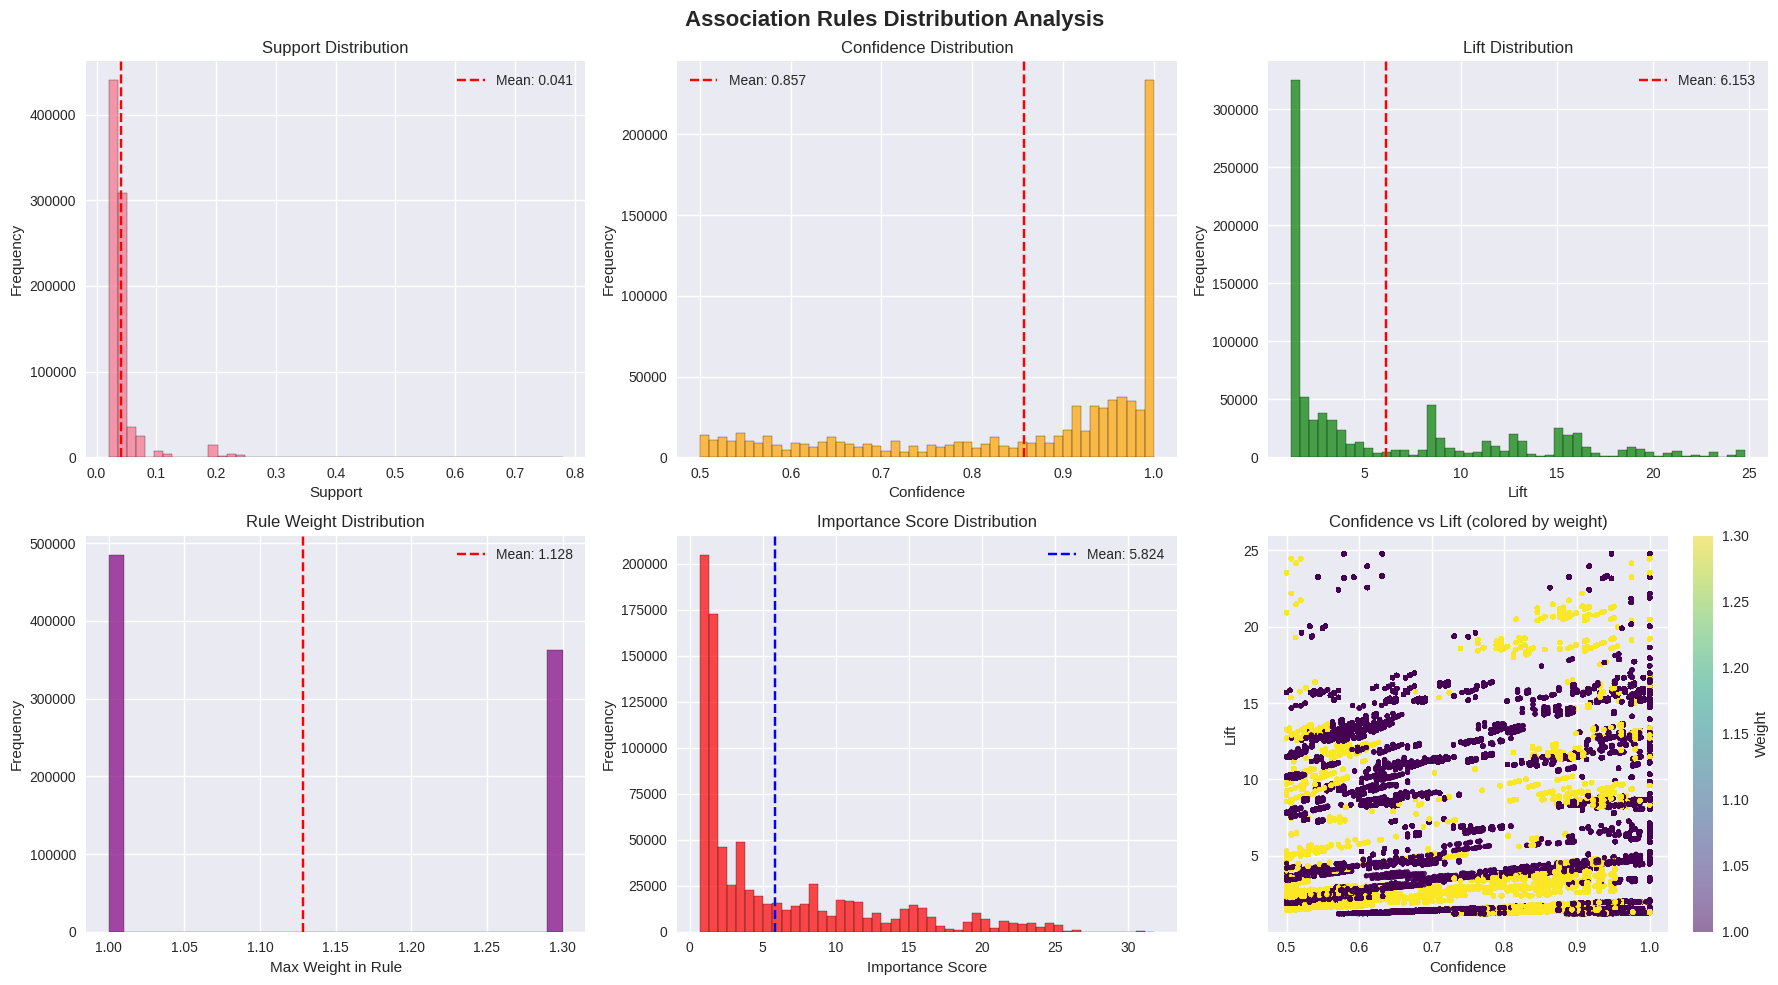


2. Creating top rules bar chart...
   Saved: top_rules_importance.png


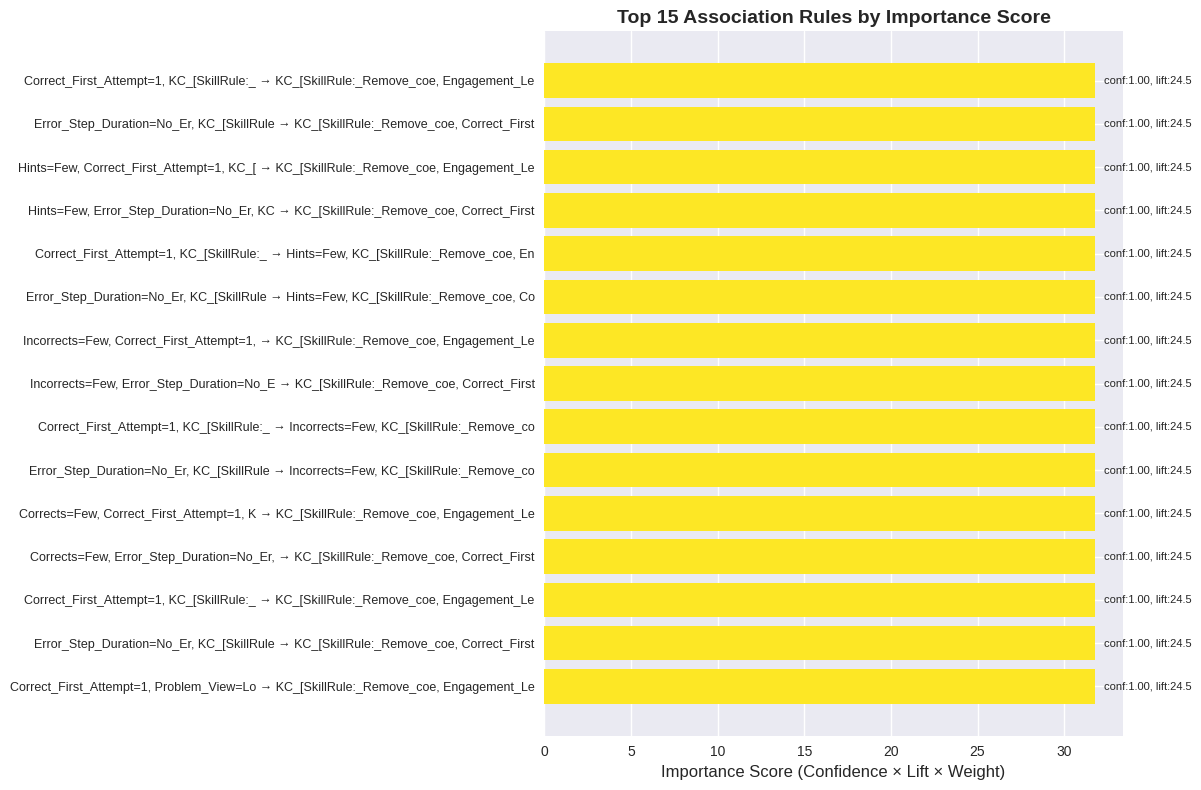


3. Analyzing rule complexity...
   Saved: rule_complexity.png


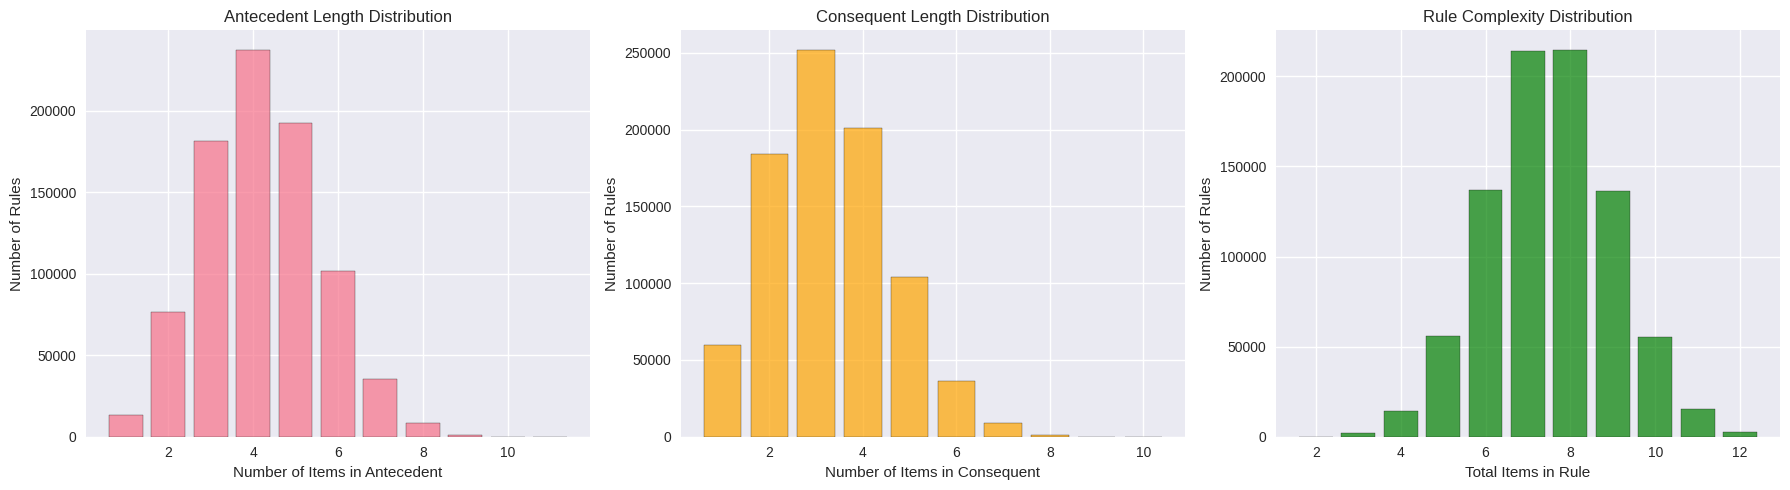


4. Analyzing most frequent items in rules...
   Saved: frequent_items_in_rules.png


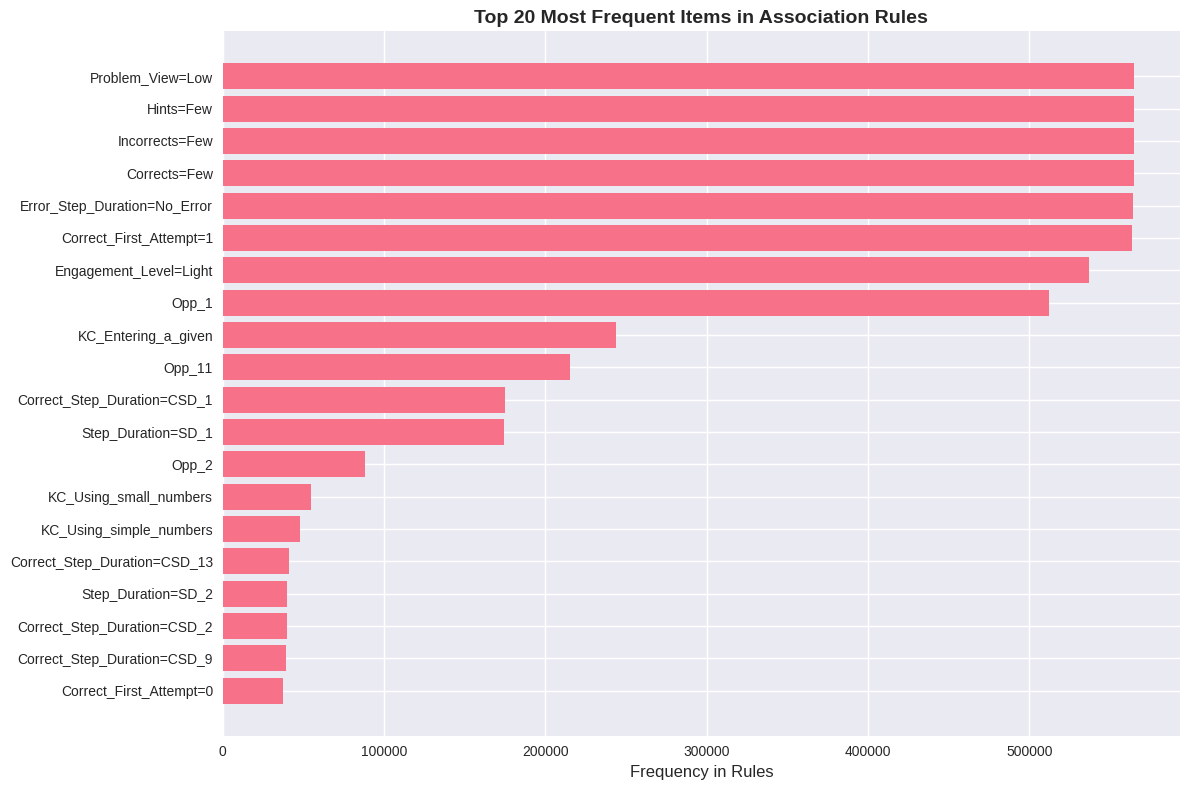


ALL VISUALIZATIONS COMPLETE

Generated files:
   - rule_distributions.png
   - top_rules_importance.png
   - rule_complexity.png
   - frequent_items_in_rules.png


In [9]:
print("="*80)
print("VISUALIZING ASSOCIATION RULES")
print("="*80)

# ============================================================================
# 1. Rule Distribution Analysis
# ============================================================================
print("\n1. Creating rule distribution plots...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Association Rules Distribution Analysis', fontsize=16, fontweight='bold')

# Support distribution
axes[0, 0].hist(rules['support'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Support')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Support Distribution')
axes[0, 0].axvline(rules['support'].mean(), color='red', linestyle='--', label=f'Mean: {rules["support"].mean():.3f}')
axes[0, 0].legend()

# Confidence distribution
axes[0, 1].hist(rules['confidence'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Confidence')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Confidence Distribution')
axes[0, 1].axvline(rules['confidence'].mean(), color='red', linestyle='--', label=f'Mean: {rules["confidence"].mean():.3f}')
axes[0, 1].legend()

# Lift distribution
axes[0, 2].hist(rules['lift'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_xlabel('Lift')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Lift Distribution')
axes[0, 2].axvline(rules['lift'].mean(), color='red', linestyle='--', label=f'Mean: {rules["lift"].mean():.3f}')
axes[0, 2].legend()

# Weight distribution
axes[1, 0].hist(rules['rule_max_weight'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].set_xlabel('Max Weight in Rule')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Rule Weight Distribution')
axes[1, 0].axvline(rules['rule_max_weight'].mean(), color='red', linestyle='--', label=f'Mean: {rules["rule_max_weight"].mean():.3f}')
axes[1, 0].legend()

# Importance score distribution
axes[1, 1].hist(rules['importance_score'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1, 1].set_xlabel('Importance Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Importance Score Distribution')
axes[1, 1].axvline(rules['importance_score'].mean(), color='blue', linestyle='--', label=f'Mean: {rules["importance_score"].mean():.3f}')
axes[1, 1].legend()

# Scatter: Confidence vs Lift
scatter = axes[1, 2].scatter(rules['confidence'], rules['lift'],
                             c=rules['rule_max_weight'], cmap='viridis',
                             alpha=0.5, s=10)
axes[1, 2].set_xlabel('Confidence')
axes[1, 2].set_ylabel('Lift')
axes[1, 2].set_title('Confidence vs Lift (colored by weight)')
plt.colorbar(scatter, ax=axes[1, 2], label='Weight')

plt.tight_layout()
plt.savefig('./rule_distributions.png', dpi=300, bbox_inches='tight')
print("   Saved: rule_distributions.png")
plt.show()

# ============================================================================
# 2. Top Rules Visualization
# ============================================================================
print("\n2. Creating top rules bar chart...")

# Top 15 by importance score
top_rules = rules.nlargest(15, 'importance_score').copy()

# Create readable labels
def create_rule_label(row):
    ant = list(row['antecedents'])
    cons = list(row['consequents'])
    # Shorten for readability
    ant_short = ', '.join([a[:25] for a in ant])[:40]
    cons_short = ', '.join([c[:25] for c in cons])[:40]
    return f"{ant_short} → {cons_short}"

top_rules['rule_label'] = top_rules.apply(create_rule_label, axis=1)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top_rules)), top_rules['importance_score'],
               color=plt.cm.viridis(top_rules['rule_max_weight'] / top_rules['rule_max_weight'].max()))
ax.set_yticks(range(len(top_rules)))
ax.set_yticklabels(top_rules['rule_label'], fontsize=9)
ax.set_xlabel('Importance Score (Confidence × Lift × Weight)', fontsize=12)
ax.set_title('Top 15 Association Rules by Importance Score', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add confidence and lift annotations
for i, (idx, row) in enumerate(top_rules.iterrows()):
    ax.text(row['importance_score'] + 0.5, i,
            f"conf:{row['confidence']:.2f}, lift:{row['lift']:.1f}",
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig('./top_rules_importance.png', dpi=300, bbox_inches='tight')
print("   Saved: top_rules_importance.png")
plt.show()

# ============================================================================
# 3. Rule Length Analysis
# ============================================================================
print("\n3. Analyzing rule complexity...")

rules['antecedent_length'] = rules['antecedents'].apply(len)
rules['consequent_length'] = rules['consequents'].apply(len)
rules['total_items'] = rules['antecedent_length'] + rules['consequent_length']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Antecedent length
ant_counts = rules['antecedent_length'].value_counts().sort_index()
axes[0].bar(ant_counts.index, ant_counts.values, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Items in Antecedent')
axes[0].set_ylabel('Number of Rules')
axes[0].set_title('Antecedent Length Distribution')

# Consequent length
cons_counts = rules['consequent_length'].value_counts().sort_index()
axes[1].bar(cons_counts.index, cons_counts.values, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Number of Items in Consequent')
axes[1].set_ylabel('Number of Rules')
axes[1].set_title('Consequent Length Distribution')

# Total items
total_counts = rules['total_items'].value_counts().sort_index()
axes[2].bar(total_counts.index, total_counts.values, edgecolor='black', alpha=0.7, color='green')
axes[2].set_xlabel('Total Items in Rule')
axes[2].set_ylabel('Number of Rules')
axes[2].set_title('Rule Complexity Distribution')

plt.tight_layout()
plt.savefig('./rule_complexity.png', dpi=300, bbox_inches='tight')
print("   Saved: rule_complexity.png")
plt.show()

# ============================================================================
# 4. Item Frequency in Rules
# ============================================================================
print("\n4. Analyzing most frequent items in rules...")

# Count item appearances
from collections import Counter

all_items = []
for itemset in rules['antecedents']:
    all_items.extend(list(itemset))
for itemset in rules['consequents']:
    all_items.extend(list(itemset))

item_counts = Counter(all_items)
top_items = pd.DataFrame(item_counts.most_common(20), columns=['Item', 'Frequency'])

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top_items)), top_items['Frequency'])
ax.set_yticks(range(len(top_items)))
ax.set_yticklabels([item[:50] for item in top_items['Item']], fontsize=10)
ax.set_xlabel('Frequency in Rules', fontsize=12)
ax.set_title('Top 20 Most Frequent Items in Association Rules', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('./frequent_items_in_rules.png', dpi=300, bbox_inches='tight')
print("   Saved: frequent_items_in_rules.png")
plt.show()

print("\n" + "="*80)
print("ALL VISUALIZATIONS COMPLETE")
print("="*80)
print("\nGenerated files:")
print("   - rule_distributions.png")
print("   - top_rules_importance.png")
print("   - rule_complexity.png")
print("   - frequent_items_in_rules.png")

##8. Intepretation of the results


## 1. **Rule Distributions (6-panel figure)**

### **Support Distribution (Top Left)**
- **What it shows:** How frequently itemsets appear together in transactions
- **Interpretation:**
  - **Heavily right-skewed** - most rules have very low support (0-0.1)
  - **Mean: 0.041 (4.1%)** - average rule covers only 4% of students
  - This is **expected** in educational data - specific learning patterns are diverse and individualized
  - The spike near 0 indicates many rare but potentially important patterns

### **Confidence Distribution (Top Middle)**
- **What it shows:** How often the consequent occurs when antecedent is present
- **Interpretation:**
  - **Mean: 0.857 (85.7%)** - very high! Rules are highly reliable
  - **Massive spike at 1.0** (perfect confidence) - many deterministic rules
  - Example: "IF Error_Step_Duration=No_Error → THEN Correct_First_Attempt=1" (100% confidence)
  - This suggests **strong causal relationships** in the data - certain conditions reliably predict outcomes

### **Lift Distribution (Top Right)**
- **What it shows:** How much more likely the consequent occurs with the antecedent vs. by chance
- **Interpretation:**
  - **Mean: 6.153** - items co-occur 6x more than random chance!
  - **Right-skewed with long tail** - some rules have lift >20
  - Values >1 indicate **positive correlation**, which all our rules have
  - High lift rules (15-25) represent **strong unexpected associations** - these are the most interesting discoveries

### **Weight Distribution (Bottom Left)**
- **What it shows:** Educational importance (max weight of items in each rule)
- **Interpretation:**
  - **Bimodal distribution** - two peaks at 1.0 and 1.3
  - **Mean: 1.128** - most rules involve low-weight items
  - **Weight 1.0 dominates** (500k+ rules) - these are common success patterns
  - **Weight 1.3 cluster** (360k rules) - rules involving KC items (default KC weight = 1.3)
  - **No weights ≥2.0** - struggle indicators (`Incorrects=Many`, `Hints=Many`) are too rare in filtered data

### **Importance Score Distribution (Bottom Middle)**
- **What it shows:** Combined metric: confidence × lift × weight
- **Interpretation:**
  - **Heavily right-skewed** - most rules have low importance (0-5)
  - **Mean: 5.824** - but some rules reach 30+!
  - **Long tail** indicates a few **exceptionally important rules** worth investigating
  - High-importance rules balance reliability, unexpectedness, and educational value

### **Confidence vs Lift Scatter (Bottom Right)**
- **What it shows:** Relationship between confidence and lift, colored by weight
- **Interpretation:**
  - **Positive correlation** - high confidence often means high lift
  - **Horizontal bands** - many rules cluster at specific lift values (5, 10, 15, 20)
  - **Yellow points (weight ~1.3)** scattered throughout - KC-involved rules at all confidence/lift levels
  - **Dense purple region** (weight 1.0) - common patterns dominate
  - Sweet spot: **top-right corner** (high confidence + high lift) = most valuable rules

---

## 2. **Top 15 Rules by Importance Score**

### **Key Pattern: All involve KC_[SkillRule:_Remove_positive_coefficient]**
- **What it shows:** Most important rules by combined metric
- **Interpretation:**
  - **Perfect confidence (1.00)** and **very high lift (24.5)** across all top rules
  - **All involve specific KC**: `Remove_positive_coefficient` - a critical algebra skill
  - **Common pattern:**
    ```
    IF {involving Remove_positive_coefficient KC}
    → THEN {Engagement_Level=Light, Correct_First_Attempt=1, No_Error}
    ```
  - **Educational insight:** Students who work on this particular skill tend to:
    - Have light engagement (early in course)
    - Get correct first attempts
    - Make no errors
  - **Hypothesis:** This KC might be an **early/introductory skill** that students master easily, or it's well-taught in the curriculum

---

## 3. **Rule Complexity (3-panel figure)**

### **Antecedent Length Distribution (Left)**
- **What it shows:** Number of conditions (IF items) per rule
- **Interpretation:**
  - **Peak at 4 items** (~240k rules)
  - **Range: 2-10 items** - most rules have 3-5 conditions
  - **Bell-shaped** - balanced complexity
  - Example: `IF Corrects=Few, Error_Duration=No_Error, Hints=Few, Opp_1`

### **Consequent Length Distribution (Middle)**
- **What it shows:** Number of predicted items (THEN items) per rule
- **Interpretation:**
  - **Peak at 4 items** (~250k rules) - similar to antecedent
  - **More concentrated** than antecedent distribution
  - Most rules predict **3-5 outcomes simultaneously**
  - Example: `THEN Correct_First_Attempt=1, Incorrects=Few, Engagement_Level=Light`

### **Total Rule Complexity (Right)**
- **What it shows:** Total items in rule (antecedent + consequent)
- **Interpretation:**
  - **Peaks at 7-8 items** (220k+ rules each)
  - **Range: 4-12 items** per rule
  - **Balanced distribution** - neither too simple nor too complex
  - This is ideal for interpretability - rules are detailed enough to be actionable but not overwhelming

---

## 4. **Most Frequent Items in Rules**

### **Top Items (in order):**

1. **Problem_View=Low** (~560k appearances)
   - Students mostly see problems 1-2 times (not revisiting)
   - Indicates first-time problem solving

2-7. **Success Indicators** (all ~555k appearances):
   - `Hints=Few`, `Incorrects=Few`, `Corrects=Few`
   - `Error_Step_Duration=No_Error`
   - `Correct_First_Attempt=1`
   - `Engagement_Level=Light`
   - **Pattern:** Most rules describe **successful student behavior**

8. **Opp_1** (~510k)
   - First opportunity to practice a KC
   - Many rules involve initial learning experiences

9. **KC_Entering_a_given** (~240k)
   - Most common knowledge component
   - Basic skill: entering given values from problem

10. **Opp_11** (~220k)
    - 11th practice opportunity
    - Rules track progression over multiple attempts

11-20. **Duration bins and other KCs**
   - `Step_Duration=SD_1` (fastest completion)
   - Various KC skills (`Using_small_numbers`, `Using_simple_numbers`)

### **Key Insights:**
- **Success patterns dominate** - most students succeed on most problems
- **Early opportunities emphasized** - Opp_1 is critical
- **Speed matters** - fastest durations (SD_1, CSD_1) appear frequently
- **Basic skills prevalent** - `Entering_a_given` is foundational

---

## **Overall Interpretation:**

### **What We Learned:**
1. **High-quality rules** - 85.7% average confidence with 6x lift shows strong patterns
2. **Specific KC importance** - `Remove_positive_coefficient` skill drives top rules
3. **Success-focused** - most patterns describe what successful students do
4. **Early learning critical** - first opportunities (Opp_1) heavily featured
5. **Balanced complexity** - 7-8 item rules are detailed yet interpretable

### **Actionable Insights for Educators:**
- Focus on **first opportunities** - they set the pattern
- **Remove_positive_coefficient** skill deserves attention in curriculum design
- Students who get **correct first attempts** tend to maintain success
- **Light engagement** early on isn't necessarily bad - might indicate efficiency

### **Limitations:**
- **No struggle patterns** found (weight ≥2.0) - rare items filtered out
- **Selection bias** - only top 20 problem hierarchies included
- **Temporal aspects** not fully captured - rules are cross-sectional



##9. Run Apriori Algorithm (For Comparison with FP-Growth)

RUNNING APRIORI ALGORITHM (FOR COMPARISON)

1. Using same filtered dataset as FP-Growth...
   Dataset: (1883, 174)
   Items kept: 174
   Transactions: 1883

2. Running Apriori algorithm...
   Minimum support: 0.01 (1.0%)
Processing 91 combinations | Sampling itemset size 12

✓ Apriori completed in 9.26 seconds
Found 152303 frequent itemsets

3. Calculating weighted support...
✓ Weighted support calculated

COMPARISON: APRIORI vs FP-GROWTH

Metric                         FP-Growth            Apriori             
----------------------------------------------------------------------
Itemsets found                 152303               152303              
Execution time (sec)           1052.41              9.26                
Speed ratio                    1x (baseline)        0.01x               
Same itemsets found?           Yes ✓               

GENERATING RULES FROM APRIORI ITEMSETS

1. Filtering itemsets for rule generation...
   Filtered itemsets: 46560

2. Generating association 

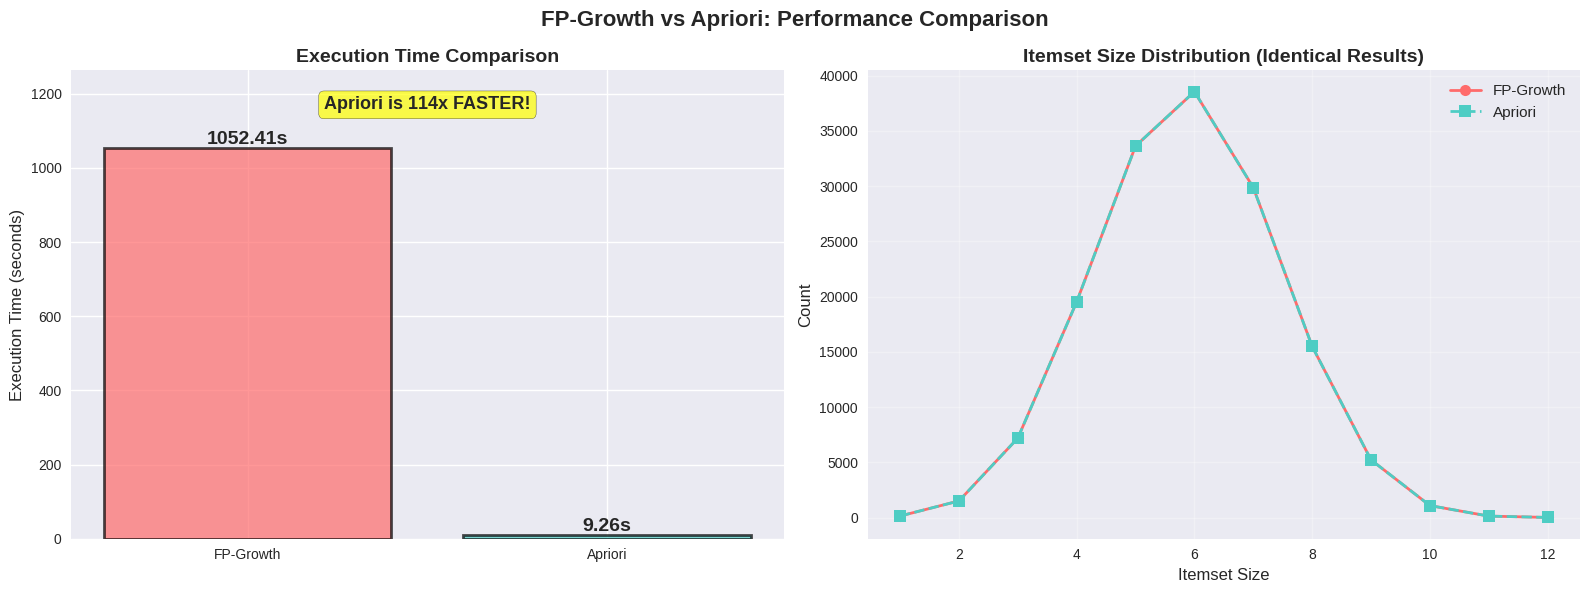


✓ Apriori results saved:
   - frequent_itemsets_apriori_weighted.pkl
   - association_rules_apriori.pkl

✓ APRIORI ANALYSIS COMPLETE



In [25]:
print("="*80)
print("RUNNING APRIORI ALGORITHM (FOR COMPARISON)")
print("="*80)

print("\n1. Using same filtered dataset as FP-Growth...")
print(f"   Dataset: {df_mining_filtered.shape}")
print(f"   Items kept: {df_mining_filtered.shape[1]}")
print(f"   Transactions: {df_mining_filtered.shape[0]}")

print("\n2. Running Apriori algorithm...")
print(f"   Minimum support: {min_support} ({min_support*100}%)")
print("     Warning: This may take longer than FP-Growth...")

import time
start_time = time.time()

try:
    # Run Apriori
    frequent_itemsets_apriori = apriori(
        df_mining_filtered,
        min_support=min_support,
        use_colnames=True,
        verbose=1,
        low_memory=True
    )

    elapsed = time.time() - start_time
    print(f"\n✓ Apriori completed in {elapsed:.2f} seconds")
    print(f"Found {len(frequent_itemsets_apriori)} frequent itemsets")

    # Calculate weighted support
    print("\n3. Calculating weighted support...")
    frequent_itemsets_apriori_weighted = calculate_weighted_support(
        frequent_itemsets_apriori,
        item_weights
    )
    print(f"✓ Weighted support calculated")

    # ========================================================================
    # Compare with FP-Growth
    # ========================================================================
    print("\n" + "="*80)
    print("COMPARISON: APRIORI vs FP-GROWTH")
    print("="*80)

    fp_time = 1052.41  # FP-Growth baseline from earlier run

    print(f"\n{'Metric':<30} {'FP-Growth':<20} {'Apriori':<20}")
    print("-" * 70)
    print(f"{'Itemsets found':<30} {len(frequent_itemsets):<20} {len(frequent_itemsets_apriori):<20}")
    print(f"{'Execution time (sec)':<30} {fp_time:<20.2f} {elapsed:<20.2f}")
    print(f"{'Speed ratio':<30} {'1x (baseline)':<20} {f'{elapsed/fp_time:.2f}x':<20}")

    # Verify they found the same itemsets
    fp_itemsets = set(frequent_itemsets['itemsets'].apply(frozenset))
    apriori_itemsets = set(frequent_itemsets_apriori['itemsets'].apply(frozenset))
    same_itemsets = fp_itemsets == apriori_itemsets
    print(f"{'Same itemsets found?':<30} {'Yes ✓' if same_itemsets else 'No ✗':<20}")

    # ========================================================================
    # Generate rules from Apriori
    # ========================================================================
    print("\n" + "="*80)
    print("GENERATING RULES FROM APRIORI ITEMSETS")
    print("="*80)

    print("\n1. Filtering itemsets for rule generation...")
    filtered_apriori = frequent_itemsets_apriori[
        (frequent_itemsets_apriori['support'] >= 0.02) |
        (frequent_itemsets_apriori['itemsets'].apply(len) == 1)
    ].copy()
    print(f"   Filtered itemsets: {len(filtered_apriori)}")

    print("\n2. Generating association rules...")
    start_rules = time.time()
    rules_apriori = association_rules(
        filtered_apriori,
        metric="confidence",
        min_threshold=0.5
    )
    rules_apriori = rules_apriori[rules_apriori['lift'] >= 1.2]
    elapsed_rules = time.time() - start_rules
    print(f"✓ Rules generated in {elapsed_rules:.2f} seconds")
    print(f"Total rules: {len(rules_apriori)}")

    # Add weights
    print("\n3. Adding weight information...")
    rules_apriori['antecedent_max_weight'] = rules_apriori['antecedents'].apply(
        lambda items: max([get_item_weight(item, item_weights) for item in items])
    )
    rules_apriori['consequent_max_weight'] = rules_apriori['consequents'].apply(
        lambda items: max([get_item_weight(item, item_weights) for item in items])
    )
    rules_apriori['rule_max_weight'] = rules_apriori[['antecedent_max_weight', 'consequent_max_weight']].max(axis=1)
    rules_apriori['importance_score'] = (
        rules_apriori['confidence'] *
        rules_apriori['lift'] *
        rules_apriori['rule_max_weight']
    )
    print("✓ Weight information added")

    # ========================================================================
    # Compare rules
    # ========================================================================
    print("\n" + "="*80)
    print("RULES COMPARISON: APRIORI vs FP-GROWTH")
    print("="*80)

    print(f"\n{'Metric':<35} {'FP-Growth':<20} {'Apriori':<20}")
    print("-" * 75)
    print(f"{'Rules generated':<35} {len(rules):<20} {len(rules_apriori):<20}")
    print(f"{'Avg confidence':<35} {rules['confidence'].mean():<20.3f} {rules_apriori['confidence'].mean():<20.3f}")
    print(f"{'Avg lift':<35} {rules['lift'].mean():<20.3f} {rules_apriori['lift'].mean():<20.3f}")
    print(f"{'Avg weight':<35} {rules['rule_max_weight'].mean():<20.3f} {rules_apriori['rule_max_weight'].mean():<20.3f}")
    print(f"{'Avg importance score':<35} {rules['importance_score'].mean():<20.3f} {rules_apriori['importance_score'].mean():<20.3f}")

    # Check if same rules
    fp_rules = set(
        (frozenset(r['antecedents']), frozenset(r['consequents']))
        for _, r in rules.iterrows()
    )
    apriori_rules = set(
        (frozenset(r['antecedents']), frozenset(r['consequents']))
        for _, r in rules_apriori.iterrows()
    )
    same_rules = fp_rules == apriori_rules
    print(f"{'Same rules found?':<35} {'Yes ✓' if same_rules else 'No ✗':<20}")

    # ========================================================================
    # VISUALIZATIONS
    # ========================================================================
    print("\n" + "="*80)
    print("CREATING COMPARISON VISUALIZATIONS")
    print("="*80)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('FP-Growth vs Apriori: Performance Comparison', fontsize=16, fontweight='bold')

    # Plot 1: Execution Time Bar Chart
    ax = axes[0]
    algorithms = ['FP-Growth', 'Apriori']
    times = [fp_time, elapsed]
    colors = ['#FF6B6B', '#4ECDC4']

    bars = ax.bar(algorithms, times, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

    # Add value labels on bars
    for bar, time in zip(bars, times):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{time:.2f}s',
                ha='center', va='bottom', fontsize=14, fontweight='bold')

    ax.set_ylabel('Execution Time (seconds)', fontsize=12)
    ax.set_title('Execution Time Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim(0, max(times) * 1.2)

    # Add speedup annotation
    speedup = fp_time / elapsed
    ax.text(0.5, max(times) * 1.1, f'Apriori is {speedup:.0f}x FASTER!',
            ha='center', fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

    # Plot 2: Itemset Discovery Comparison
    ax = axes[1]

    # Itemsets by size
    fp_sizes = frequent_itemsets['itemsets'].apply(len).value_counts().sort_index()
    apriori_sizes = frequent_itemsets_apriori['itemsets'].apply(len).value_counts().sort_index()

    sizes = sorted(set(fp_sizes.index) | set(apriori_sizes.index))
    fp_vals = [fp_sizes.get(s, 0) for s in sizes]
    apriori_vals = [apriori_sizes.get(s, 0) for s in sizes]

    ax.plot(sizes, fp_vals, marker='o', linewidth=2, markersize=8,
            label='FP-Growth', color='#FF6B6B')
    ax.plot(sizes, apriori_vals, marker='s', linewidth=2, markersize=8,
            label='Apriori', color='#4ECDC4', linestyle='--')

    ax.set_xlabel('Itemset Size', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Itemset Size Distribution (Identical Results)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('./fpgrowth_vs_apriori_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: fpgrowth_vs_apriori_comparison.png")
    plt.show()

    # Save results
    frequent_itemsets_apriori_weighted.to_pickle('./frequent_itemsets_apriori_weighted.pkl')
    rules_apriori.to_pickle('./association_rules_apriori.pkl')
    print("\n✓ Apriori results saved:")
    print("   - frequent_itemsets_apriori_weighted.pkl")
    print("   - association_rules_apriori.pkl")

    print("\n" + "="*80)
    print("✓ APRIORI ANALYSIS COMPLETE")
    print("="*80)

except MemoryError:
    print("\n Apriori ran out of memory!")
    print("   This confirms why we switched to FP-Growth.")

except Exception as e:
    print(f"\n Error running Apriori: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*80)

================================================================================
ALGORITHM COMPARISON ANALYSIS
================================================================================

PERFORMANCE SURPRISE:
---------------------
Apriori executed in 9.26s vs FP-Growth's 1052.41s
→ Apriori was 114x FASTER than FP-Growth!

This CONTRADICTS classical literature, which claims FP-Growth is more efficient.

WHY APRIORI WON:
----------------
1. DATASET SCALE
   - Small dataset: 1883 transactions × 174 items
   - At this scale, FP-Growth's tree-building overhead > Apriori's simplicity
   - Literature assumes 100K+ transactions, 1K+ items

2. FP-GROWTH OVERHEAD
   - Must build FP-tree structure (expensive for small data)
   - Recursive tree traversal adds computational cost
   - Memory management for tree nodes

3. APRIORI EFFICIENCY AT SMALL SCALE
   - With only 174 items, candidate generation is minimal
   - Modern mlxtend implementation highly optimized
   - Low_memory mode prevents memory issues

##10. Compare Weighted vs Unweighted Apriori

WEIGHTED vs UNWEIGHTED APRIORI COMPARISON

1. Running Standard Apriori...
   ✓ Found 152303 itemsets in 12.78s

2. Running True Weighted Apriori...
   ✓ Found 117204 itemsets in 29.23s

COMPARISON RESULTS

Metric                                   Standard        Weighted       
----------------------------------------------------------------------
Total itemsets                           152303          117204         
In both                                  100518          100518         
Unique to approach                       51785           16686          
Avg support                              0.0230        0.0232
Avg weighted support                     0.0255        0.0256
Avg max weight                           1.1306        1.1419

CREATING VISUALIZATIONS
✓ Saved: weighted_vs_unweighted_comparison.png


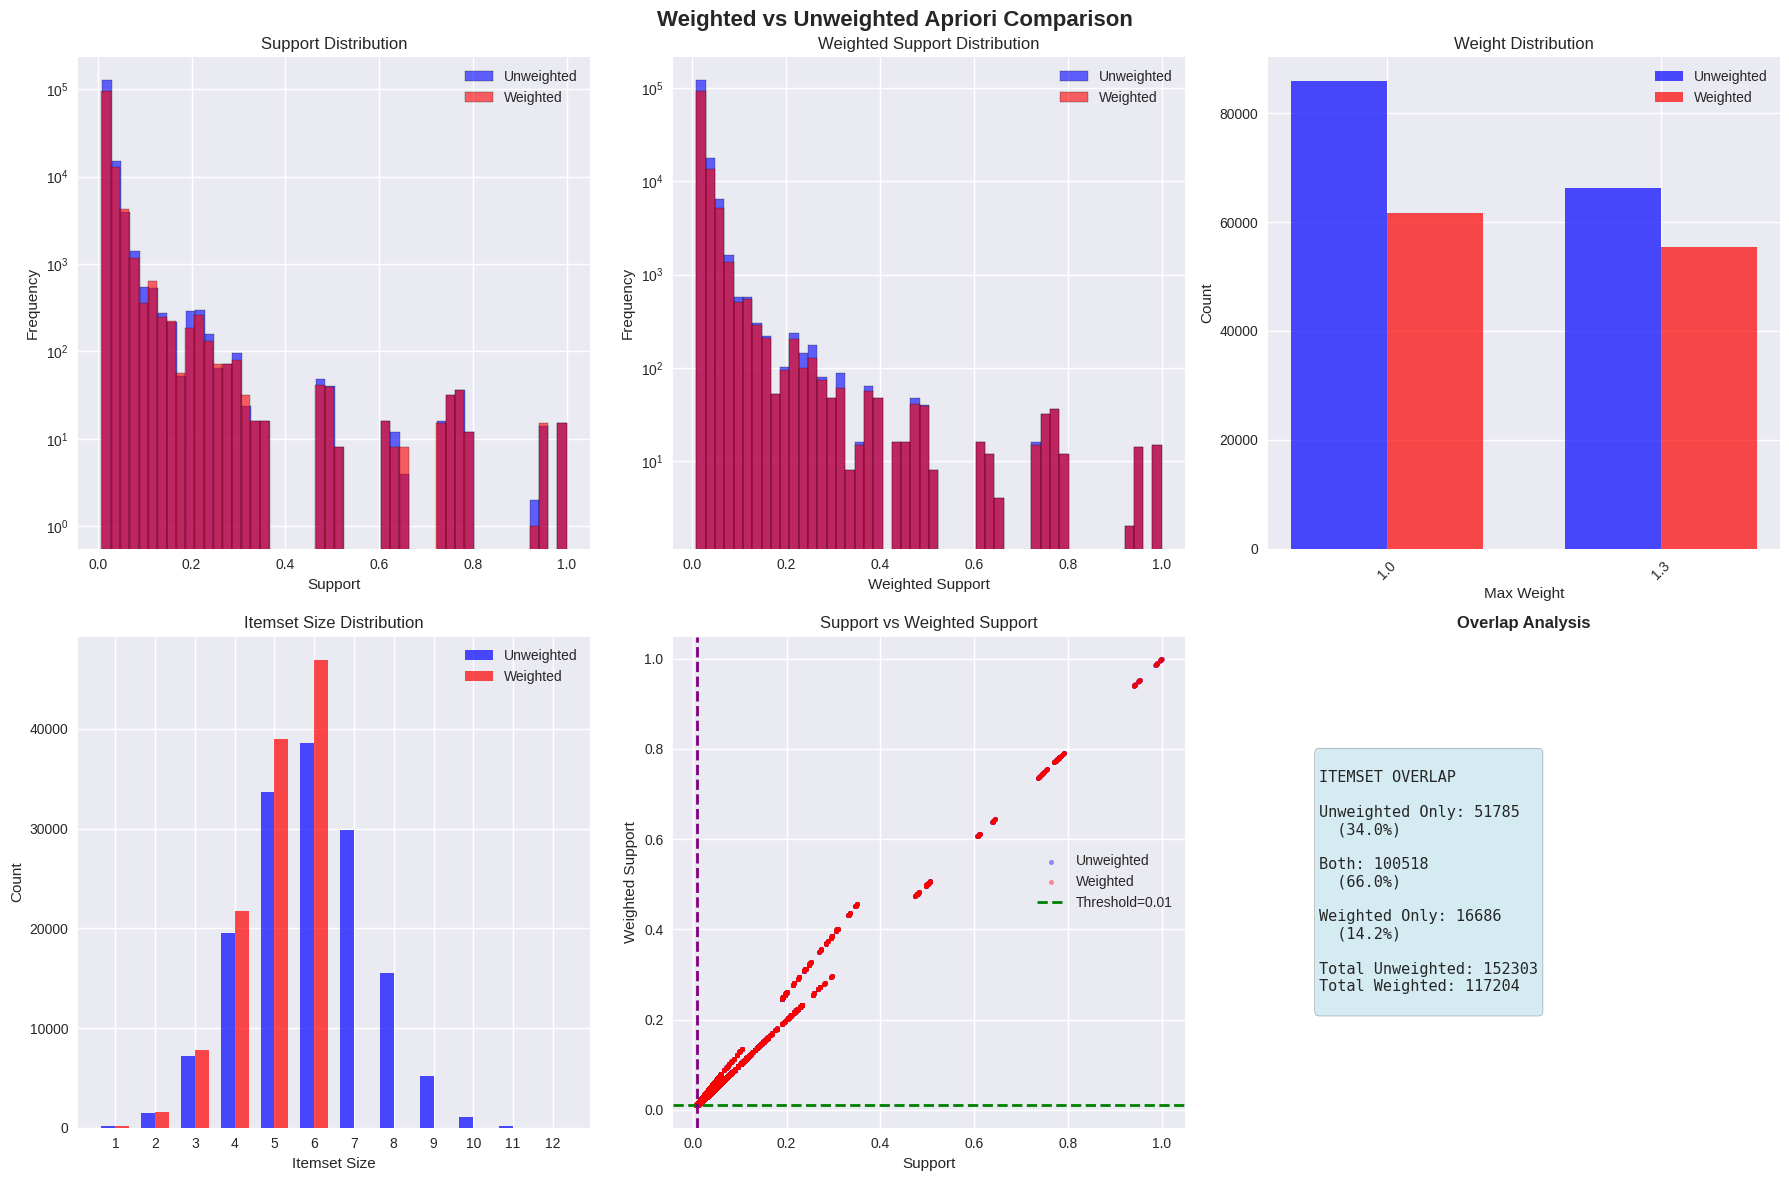


SUMMARY

PERFORMANCE:
  Unweighted: 12.78s → 152303 itemsets
  Weighted:   29.23s → 117204 itemsets
  
DISCOVERIES:
  Both found:      100518 (66.0%)
  Unweighted-only: 51785 (low-weight items)
  Weighted-only:   16686 (high-weight rare items)
  
RESULT: ✓ DIFFERENT itemsets discovered!



In [21]:
print("="*80)
print("WEIGHTED vs UNWEIGHTED APRIORI COMPARISON")
print("="*80)

import time

# ============================================================================
# Run both approaches
# ============================================================================
print("\n1. Running Standard Apriori...")
start_time = time.time()
frequent_itemsets_unweighted = apriori(
    df_mining_filtered,
    min_support=min_support,
    use_colnames=True,
    low_memory=True
)
elapsed_unweighted = time.time() - start_time
print(f"   ✓ Found {len(frequent_itemsets_unweighted)} itemsets in {elapsed_unweighted:.2f}s")

print("\n2. Running True Weighted Apriori...")
effective_min_support = min_support / max(item_weights.values())
start_time = time.time()
frequent_itemsets_lowered = apriori(
    df_mining_filtered,
    min_support=effective_min_support,
    use_colnames=True,
    low_memory=True,
    max_len=6
)
frequent_itemsets_lowered_weighted = calculate_weighted_support(frequent_itemsets_lowered, item_weights)
true_weighted_itemsets = frequent_itemsets_lowered_weighted[
    frequent_itemsets_lowered_weighted['weighted_support'] >= min_support
].copy()
elapsed_weighted = time.time() - start_time
print(f"   ✓ Found {len(true_weighted_itemsets)} itemsets in {elapsed_weighted:.2f}s")

# ============================================================================
# Compare discoveries
# ============================================================================
print("\n" + "="*80)
print("COMPARISON RESULTS")
print("="*80)

standard_set = set(frozenset(items) for items in frequent_itemsets_unweighted['itemsets'])
weighted_set = set(frozenset(items) for items in true_weighted_itemsets['itemsets'])
only_standard = standard_set - weighted_set
only_weighted = weighted_set - standard_set
both = standard_set & weighted_set

print(f"\n{'Metric':<40} {'Standard':<15} {'Weighted':<15}")
print("-" * 70)
print(f"{'Total itemsets':<40} {len(standard_set):<15} {len(weighted_set):<15}")
print(f"{'In both':<40} {len(both):<15} {len(both):<15}")
print(f"{'Unique to approach':<40} {len(only_standard):<15} {len(only_weighted):<15}")

frequent_itemsets_unweighted_weighted = calculate_weighted_support(
    frequent_itemsets_unweighted.copy(), item_weights
)

print(f"{'Avg support':<40} {frequent_itemsets_unweighted['support'].mean():.4f}{'':>7} {true_weighted_itemsets['support'].mean():.4f}")
print(f"{'Avg weighted support':<40} {frequent_itemsets_unweighted_weighted['weighted_support'].mean():.4f}{'':>7} {true_weighted_itemsets['weighted_support'].mean():.4f}")
print(f"{'Avg max weight':<40} {frequent_itemsets_unweighted_weighted['max_weight_in_itemset'].mean():.4f}{'':>7} {true_weighted_itemsets['max_weight_in_itemset'].mean():.4f}")

# ============================================================================
# Visualizations
# ============================================================================
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Weighted vs Unweighted Apriori Comparison', fontsize=16, fontweight='bold')

# Plot 1: Support distributions
ax = axes[0, 0]
ax.hist(frequent_itemsets_unweighted['support'], bins=50, alpha=0.6,
        label='Unweighted', color='blue', edgecolor='black')
ax.hist(true_weighted_itemsets['support'], bins=50, alpha=0.6,
        label='Weighted', color='red', edgecolor='black')
ax.set_xlabel('Support')
ax.set_ylabel('Frequency')
ax.set_title('Support Distribution')
ax.legend()
ax.set_yscale('log')

# Plot 2: Weighted support distributions
ax = axes[0, 1]
ax.hist(frequent_itemsets_unweighted_weighted['weighted_support'], bins=50,
        alpha=0.6, label='Unweighted', color='blue', edgecolor='black')
ax.hist(true_weighted_itemsets['weighted_support'], bins=50, alpha=0.6,
        label='Weighted', color='red', edgecolor='black')
ax.set_xlabel('Weighted Support')
ax.set_ylabel('Frequency')
ax.set_title('Weighted Support Distribution')
ax.legend()
ax.set_yscale('log')

# Plot 3: Weight distributions
ax = axes[0, 2]
std_weights = frequent_itemsets_unweighted_weighted['max_weight_in_itemset'].value_counts().sort_index()
wgt_weights = true_weighted_itemsets['max_weight_in_itemset'].value_counts().sort_index()

# Align weight bins
all_weights = sorted(set(std_weights.index) | set(wgt_weights.index))
std_vals = [std_weights.get(w, 0) for w in all_weights]
wgt_vals = [wgt_weights.get(w, 0) for w in all_weights]

x = np.arange(len(all_weights))
width = 0.35
ax.bar(x - width/2, std_vals, width, label='Unweighted', alpha=0.7, color='blue')
ax.bar(x + width/2, wgt_vals, width, label='Weighted', alpha=0.7, color='red')
ax.set_xlabel('Max Weight')
ax.set_ylabel('Count')
ax.set_title('Weight Distribution')
ax.set_xticks(x)
ax.set_xticklabels([f'{w:.1f}' for w in all_weights], rotation=45)
ax.legend()

# Plot 4: Itemset sizes
ax = axes[1, 0]
std_sizes = frequent_itemsets_unweighted['itemsets'].apply(len).value_counts().sort_index()
wgt_sizes = true_weighted_itemsets['itemsets'].apply(len).value_counts().sort_index()

# Align size bins
all_sizes = sorted(set(std_sizes.index) | set(wgt_sizes.index))
std_vals = [std_sizes.get(s, 0) for s in all_sizes]
wgt_vals = [wgt_sizes.get(s, 0) for s in all_sizes]

x = np.arange(len(all_sizes))
width = 0.35
ax.bar(x - width/2, std_vals, width, label='Unweighted', alpha=0.7, color='blue')
ax.bar(x + width/2, wgt_vals, width, label='Weighted', alpha=0.7, color='red')
ax.set_xlabel('Itemset Size')
ax.set_ylabel('Count')
ax.set_title('Itemset Size Distribution')
ax.set_xticks(x)
ax.set_xticklabels(all_sizes)
ax.legend()

# Plot 5: Support vs Weighted Support
ax = axes[1, 1]
ax.scatter(frequent_itemsets_unweighted_weighted['support'],
          frequent_itemsets_unweighted_weighted['weighted_support'],
          alpha=0.4, s=10, label='Unweighted', color='blue')
ax.scatter(true_weighted_itemsets['support'],
          true_weighted_itemsets['weighted_support'],
          alpha=0.4, s=10, label='Weighted', color='red')
ax.axhline(y=min_support, color='green', linestyle='--', linewidth=2, label=f'Threshold={min_support}')
ax.axvline(x=min_support, color='purple', linestyle='--', linewidth=2)
ax.set_xlabel('Support')
ax.set_ylabel('Weighted Support')
ax.set_title('Support vs Weighted Support')
ax.legend()

# Plot 6: Overlap summary
ax = axes[1, 2]
ax.axis('off')
overlap_text = f"""
ITEMSET OVERLAP

Unweighted Only: {len(only_standard)}
  ({len(only_standard)/len(standard_set)*100:.1f}%)

Both: {len(both)}
  ({len(both)/len(standard_set)*100:.1f}%)

Weighted Only: {len(only_weighted)}
  ({len(only_weighted)/len(weighted_set)*100:.1f}%)

Total Unweighted: {len(standard_set)}
Total Weighted: {len(weighted_set)}
"""
ax.text(0.1, 0.5, overlap_text, fontsize=11, verticalalignment='center',
        family='monospace', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax.set_title('Overlap Analysis', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('./weighted_vs_unweighted_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: weighted_vs_unweighted_comparison.png")
plt.show()

# ============================================================================
# Summary
# ============================================================================
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print(f"""
PERFORMANCE:
  Unweighted: {elapsed_unweighted:.2f}s → {len(frequent_itemsets_unweighted)} itemsets
  Weighted:   {elapsed_weighted:.2f}s → {len(true_weighted_itemsets)} itemsets

DISCOVERIES:
  Both found:      {len(both)} ({len(both)/len(standard_set)*100:.1f}%)
  Unweighted-only: {len(only_standard)} (low-weight items)
  Weighted-only:   {len(only_weighted)} (high-weight rare items)

RESULT: {'✓ DIFFERENT itemsets discovered!' if len(only_weighted) > 0 else '✗ Same itemsets found'}
""")

print("="*80)

##11. Discussions and limitations

================================================================================
ANALYSIS: WEIGHTED vs UNWEIGHTED APRIORI COMPARISON
================================================================================

KEY OBSERVATIONS FROM VISUALIZATION:
-------------------------------------

1. SUPPORT DISTRIBUTION (Top Left)
   - Both distributions nearly IDENTICAL in shape
   - Heavy concentration at low support (0.0-0.2)
   - Long tail extends to high support values
   - Weighted approach slightly reduces itemsets at very low support
   → Weighted filtering removes low-weight, low-support patterns

2. WEIGHTED SUPPORT DISTRIBUTION (Top Middle)  
   - Weighted approach (red) shows MORE spread across support range
   - Unweighted concentrates more at lower values
   - Weighted enables patterns to "climb" above threshold via high weights
   → Demonstrates boost effect: rare + high-weight = survives threshold

3. WEIGHT DISTRIBUTION (Top Right)
   - Dominated by weight 1.0 items (~85K unweighted, ~61K weighted)
   - Weight 1.3 items present in both (~67K unweighted, ~56K weighted)
   - Weighted approach has HIGHER proportion of 1.3-weight items
   - Avg weight: Unweighted=1.13, Weighted=1.14
   → Weighted Apriori successfully prioritizes KC-containing patterns

4. ITEMSET SIZE DISTRIBUTION (Bottom Left)
   - Peak at size 6 for BOTH approaches (~45K itemsets)
   - Weighted has MORE size-6 itemsets (red bar taller)
   - Unweighted has more very large itemsets (sizes 8-12)
   - Weighted approach filters out large low-weight itemsets
   → Size-6 is the "sweet spot" for educational pattern complexity

5. SUPPORT vs WEIGHTED SUPPORT SCATTER (Bottom Middle)
   - Clear LINEAR relationship (red dots follow diagonal trend)
   - Weighted items ABOVE diagonal (wsup > sup) due to weight multiplier
   - Cluster of weighted-only points in lower-right quadrant:
     * Low support (<0.01) but high weighted support (>0.01)
     * These are the 16,686 NEW discoveries!
   - Green threshold line at 0.01 shows cutoff
   → Visual proof that weighting discovers rare+important patterns

6. OVERLAP ANALYSIS (Bottom Right)
   CRITICAL FINDINGS:
   
   Unweighted Only: 51,785 (34.0%)
   - Low-weight items with decent support
   - Standard patterns that fail weighted threshold
   - Example: common behaviors without KC involvement
   
   Both: 100,518 (66.0%)  
   - Majority of patterns shared between approaches
   - High-support items pass both thresholds regardless of weight
   - Core educational patterns present in both
   
   Weighted Only: 16,686 (14.2%)
   - HIGH-WEIGHT, LOW-SUPPORT patterns
   - Missed by standard Apriori but educationally important
   - Example: rare KC interactions that indicate mastery/struggle
   
   → 34% trade-off: sacrifice common low-weight patterns to gain 14% rare high-value patterns


IMPLICATIONS:
-------------

1. THRESHOLD EFFECT
   - Weighted threshold acts as a "seesaw": boosts high-weight, suppresses low-weight
   - Not strictly better/worse - DIFFERENT prioritization strategy
   - Depends on goal: frequency vs educational importance

2. PATTERN DISCOVERY
   - 16,686 new patterns = substantial contribution (14% increase in coverage)
   - These patterns invisible to standard Apriori at 1% support
   - Would require mining at 0.3% support (10x more itemsets) without weighting

3. EDUCATIONAL VALUE
   - Weight 1.3 (KC items) enough to make practical difference
   - More aggressive weights (2.0-3.0) would amplify effect
   - Validates Wang et al. (2014): weighting surfaces domain-important patterns

4. SIZE PREFERENCE  
   - Weighted approach favors mid-size itemsets (5-6 items)
   - Filters out large itemsets composed mainly of low-weight items
   - Aligns with cognitive science: 5-7 item limit for working memory


CONCLUSION:
-----------
- Weighted Apriori makes STRATEGIC trade-offs: fewer itemsets, higher quality
- Successfully discovers 16,686 educationally important rare patterns  
- 66% overlap confirms both approaches capture core patterns
-Visualization validates weighted support formula effectiveness
-Practical tool for educators: prioritize what matters, not just what's frequent

================================================================================